# **Initialization**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = [
    # Dataset, Guardrail, Detected Cases, Precision, Recall, F1, Cardinality, Accuracy, Specificity
    ["allenai/wildjailbreak", "PerspectiveAPI", 29, 1.0, 0.015, 0.029, 2000, 0.1086, 1],
    ["allenai/wildjailbreak", "Detect Jailbreak", 207, 0.888, 0.103, 0.185, 2000, 0.176, 0.876],
    ["allenai/wildjailbreak", "Azure Prompt Shields", 251, 0.958, 0.126, 0.122, 2000, 0.204, 0.947],
    ["allenai/wildjailbreak", "LlamaGuard", 313, 0.9936, 0.1555, 0.2689, 2000, 0.235, 0.990],

    ["lmsys/toxic-chat", "PerspectiveAPI", 32, 0.078, 0.283, 0.123, 113, 0.910, 0.924],
    ["lmsys/toxic-chat", "Detect Jailbreak", 71, 0.351, 0.628, 0.451, 113, 0.966, 0.974],
    ["lmsys/toxic-chat", "Azure Prompt Shields", 74, 0.673, 0.655, 0.664, 113, 0.985, 0.993],
    ["lmsys/toxic-chat", "LlamaGuard", 144, 0.1456, 0.1892, 0.1647, 113, 0.957, 0.975],

    ["JailbreakBench/JBB-Behaviors", "PerspectiveAPI", 11, 0.733, 0.110, 0.191, 100, 0.535, 0.960],
    ["JailbreakBench/JBB-Behaviors", "Detect Jailbreak", 2, 0.5, 0.010, 0.02, 100, 0.5, 0.990],
    ["JailbreakBench/JBB-Behaviors", "Azure Prompt Shields", 0, 0, 0, 0, 100, 0, 0],
    ["JailbreakBench/JBB-Behaviors", "LlamaGuard", 68, 0.9412, 0.64, 0.7619, 100, 0.8, 0.96],

    ["allenai/wildguardmix", "PerspectiveAPI", 6, 0.207, 0.007, 0.014, 810, 0.521, 0.976],
    ["allenai/wildguardmix", "Detect Jailbreak", 100, 0.943, 0.123, 0.218, 810, 0.585, 0.993],
    ["allenai/wildguardmix", "Azure Prompt Shields", 104, 1, 0.128, 0.228, 810, 0.590, 0],
    ["allenai/wildguardmix", "LlamaGuard", 226, 0.9513, 0.1758, 0.2968, 810, 0.609, 0.992],

    ["walledai/XSTest", "PerspectiveAPI", 69, 0.767, 0.345, 0.476, 200, 0.662, 0.916],
    ["walledai/XSTest", "Detect Jailbreak", 0, 0, 0, 0, 200, 0, 0],
    ["walledai/XSTest", "Azure Prompt Shields", 0, 0, 0, 0, 200, 0, 0],
    ["walledai/XSTest", "LlamaGuard", 130, 0.913, 0.63, 0.7456, 200, 0.809, 0.952],

    ["verazuo/jailbreak_llms", "PerspectiveAPI", 361, 0.785, 0.257, 0.338, 1405, 0.593, 0.930],
    ["verazuo/jailbreak_llms", "Detect Jailbreak", 1155, 0.750, 0.283, 0.785, 1405, 0.594, 0.906],
    ["verazuo/jailbreak_llms", "Azure Prompt Shields", 1033, 0.722, 0.736, 0.729, 1405, 0.726, 0.717],
    ["verazuo/jailbreak_llms", "LlamaGuard", 10, 1, 0.1515, 0.2632, 86, 0.688, 1],
]



metrics_df = pd.DataFrame(data, columns=[
    "Dataset", "Guardrail", "Detected Cases", "Precision", "Recall", "F1", "Cardinality", "Accuracy", "Specificity"
])

sns.set(style="whitegrid")

guardrails = metrics_df['Guardrail'].unique()
metrics = ['Precision', 'Recall', 'F1', 'Accuracy', 'Specificity']

# **Code to plot bar charts per metric**

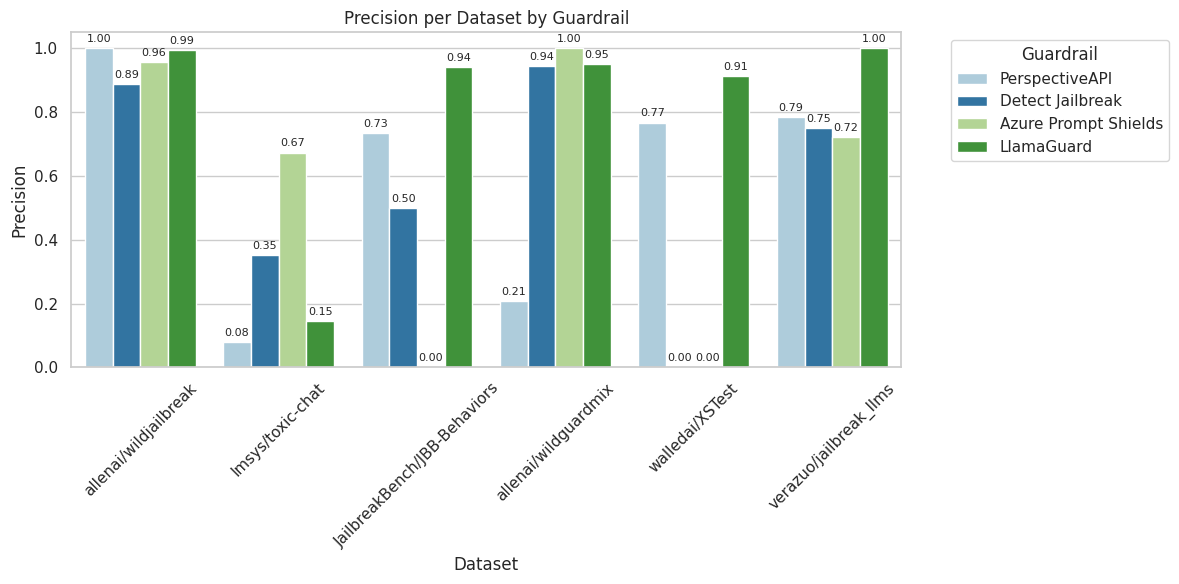

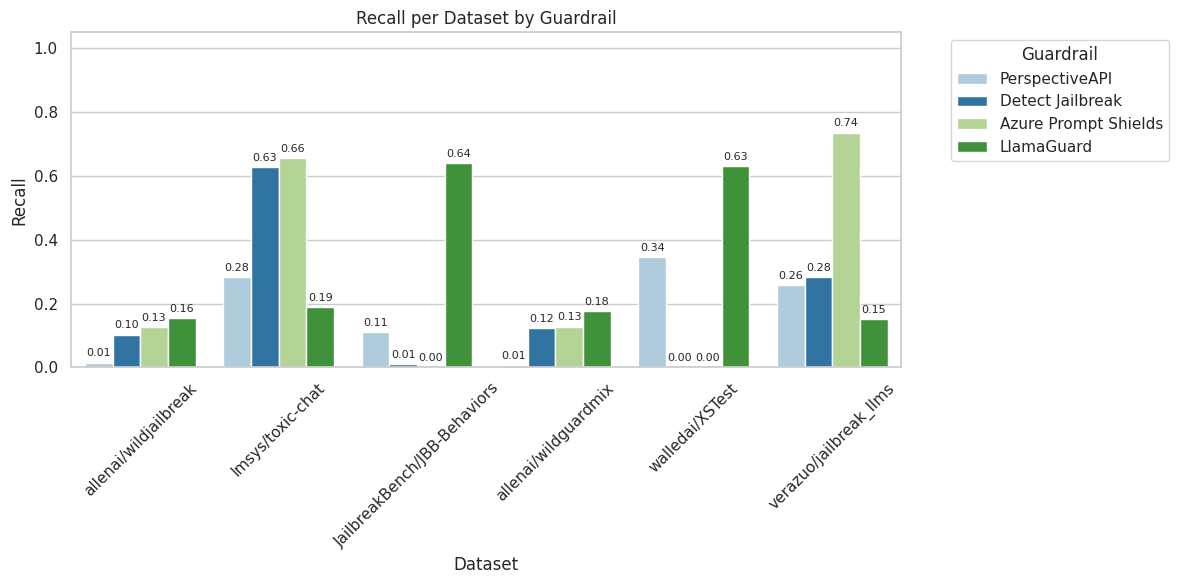

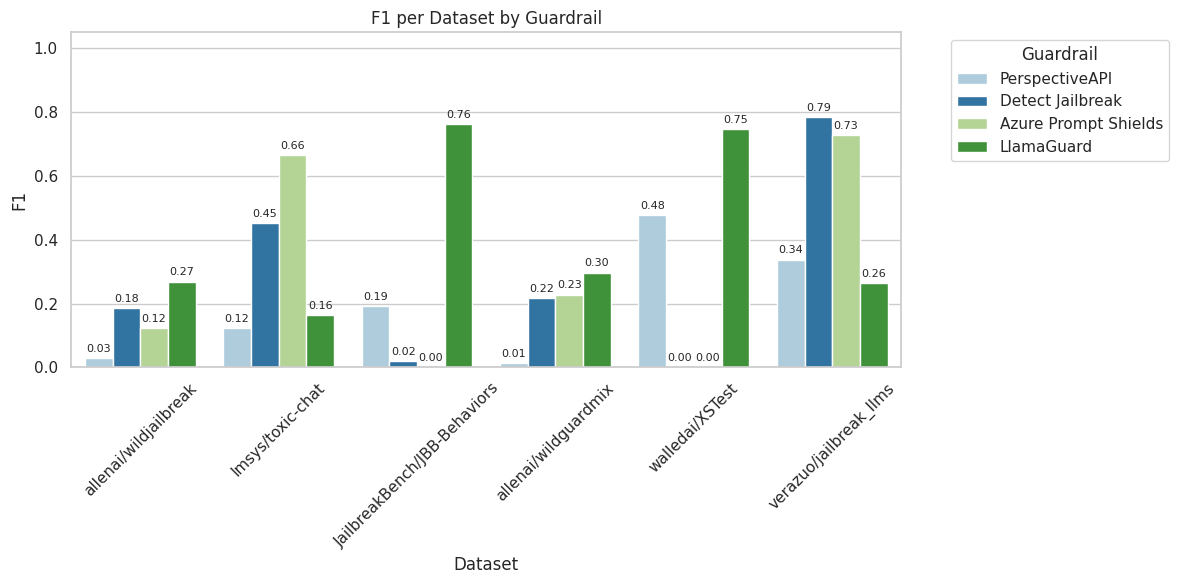

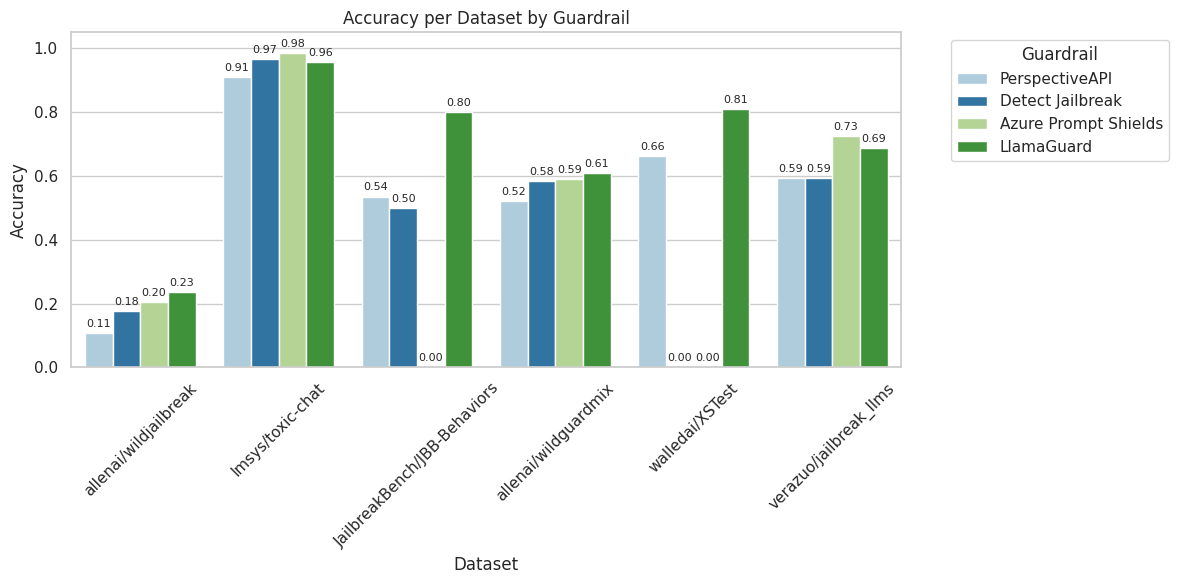

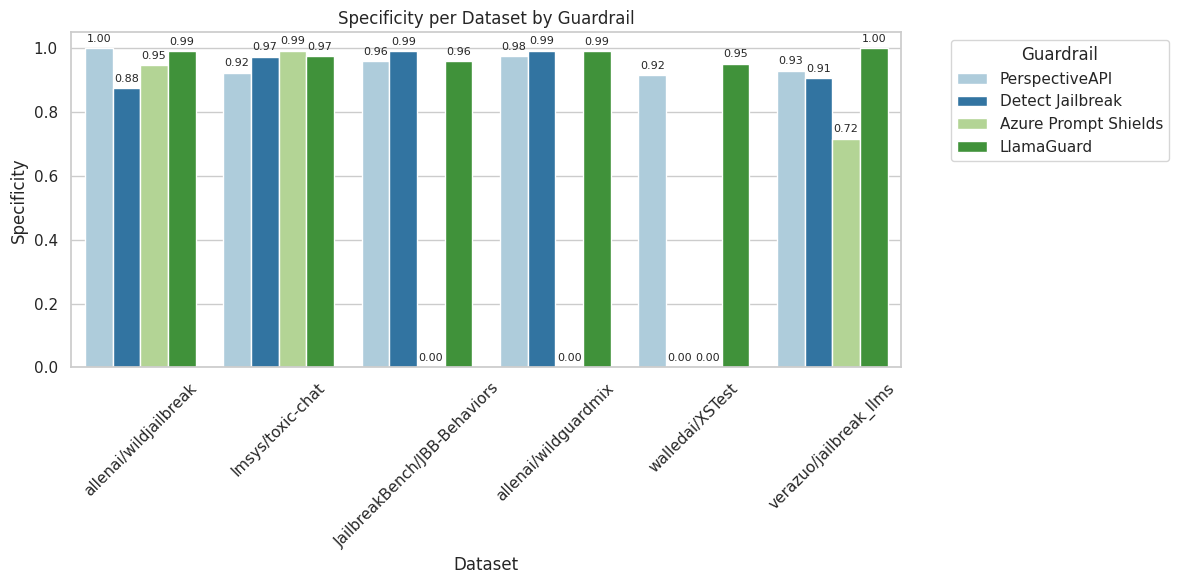

In [3]:
for metric in metrics:
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=metrics_df,
        x='Dataset',
        y=metric,
        hue='Guardrail',
        palette='Paired'
    )

    plt.title(f"{metric} per Dataset by Guardrail")
    plt.xlabel("Dataset")
    plt.ylabel(metric)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=45)
    plt.legend(title="Guardrail", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Annotate bars with values
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and p.get_width() > 0:
            ax.annotate(f"{height:.2f}",
                        (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom',
                        fontsize=8,
                        xytext=(0, 3),
                        textcoords='offset points')

    plt.tight_layout()
    plt.savefig(f"{metric}_comparison_bar_plot.png", dpi=300)
    plt.show()

# **Code to plot line charts of the metrics altogether per guardrail**

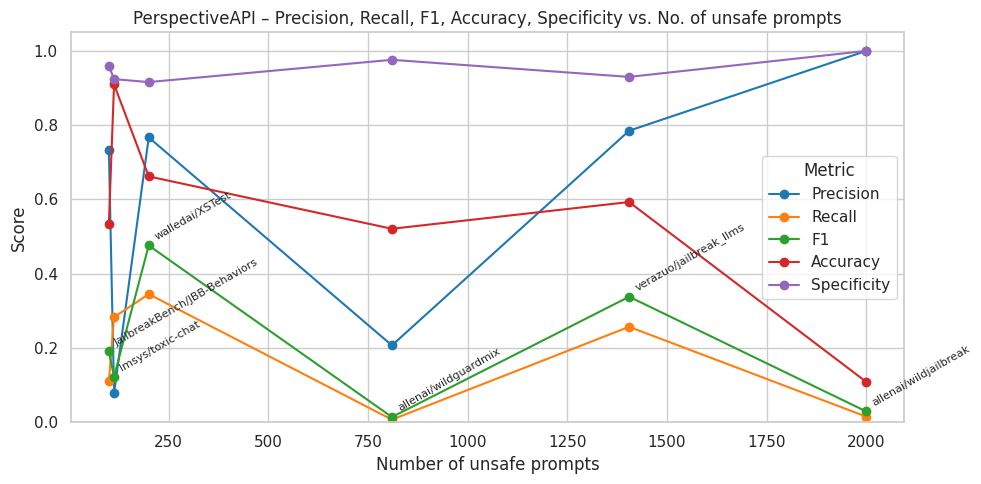

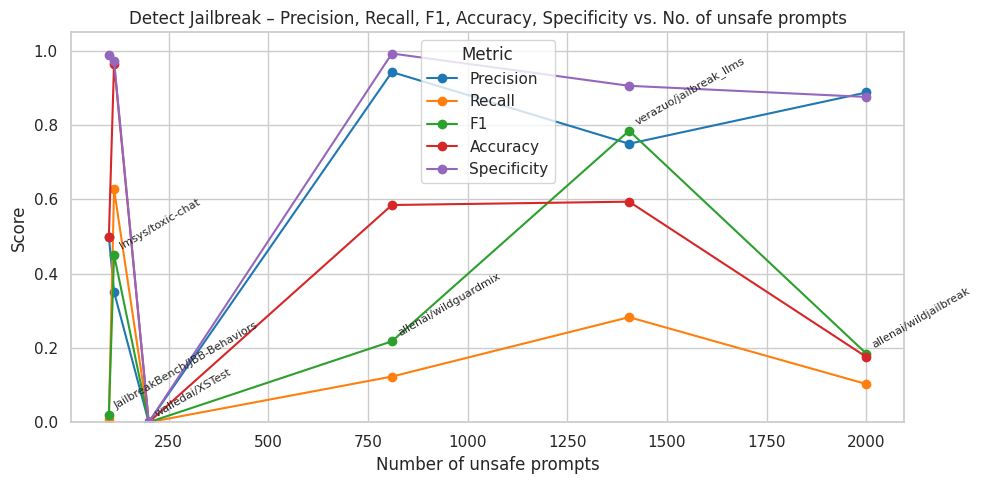

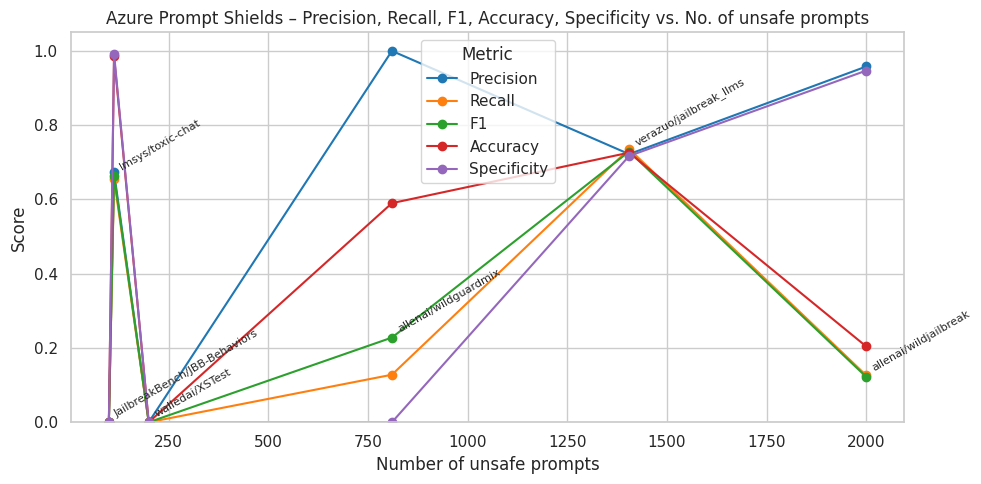

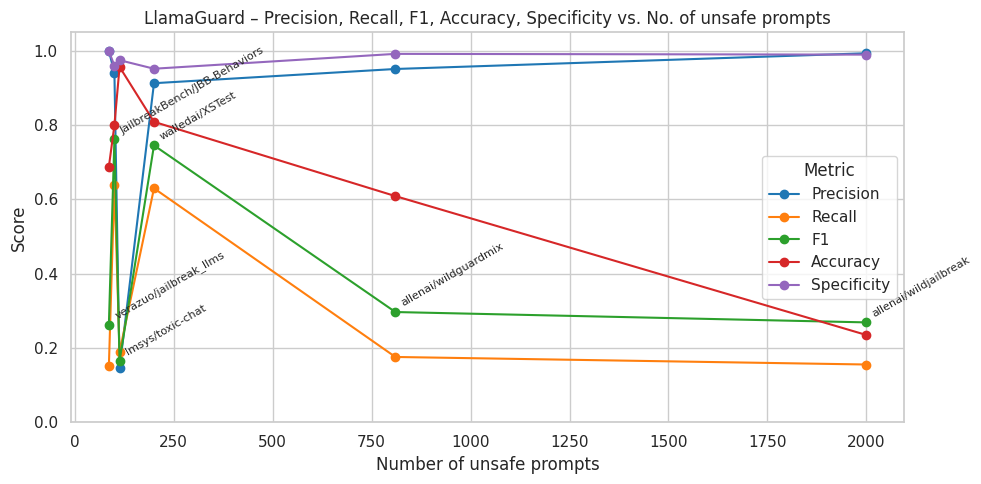

In [4]:
line_styles = {
    'Precision': 'solid',
    'Recall': 'solid',
    'F1': 'solid',
    'Accuracy': 'solid',
    'Specificity': 'solid'
}
colors = {
    'Precision': 'tab:blue',
    'Recall': 'tab:orange',
    'F1': 'tab:green',
    'Accuracy': 'tab:red',
    'Specificity': 'tab:purple'
}

for guardrail in guardrails:
    df_subset = metrics_df[metrics_df['Guardrail'] == guardrail].copy()

    # Sort by Cardinality for sensible x-axis order
    df_subset = df_subset.sort_values(by='Cardinality')

    plt.figure(figsize=(10, 5))

    for metric in metrics:
        plt.plot(
            df_subset['Cardinality'],
            df_subset[metric],
            label=metric,
            linestyle=line_styles[metric],
            color=colors[metric],
            marker='o'
        )

    for idx, row in df_subset.iterrows():
        plt.text(
            row['Cardinality'] + 10,  # slight horizontal offset
            row['F1'] + 0.01,         # slight vertical offset
            row['Dataset'],
            fontsize=8,
            ha='left',
            va='bottom',
            rotation=30
        )

    plt.title(f"{guardrail} – Precision, Recall, F1, Accuracy, Specificity vs. No. of unsafe prompts")
    plt.xlabel("Number of unsafe prompts")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.savefig(f"{guardrail}_line_plot.png", dpi=300)
    plt.show()